# Air Quality in Nairobi — PM2.5 Prediction (Regression)

A regression pipeline to estimate **daily PM2.5 concentrations** across Nairobi's AirQo sensor network (74 sites, full year 2025), enabling better coverage where measurements are missing and providing a foundation for air quality forecasting.

> **Scope note:** this version focuses on **regression only** — predicting the continuous PM2.5 value (µg/m³). The AQI-category classification branch (Good/Moderate/Unhealthy, SMOTE balancing, Logistic Regression / Random Forest classifiers) has been removed to keep the notebook focused on a single, clearly-justified task.

## 1. Problem Statement

Nairobi runs one of the densest low-cost air-quality monitoring networks in Africa (74 AirQo sites, reporting daily through 2025), yet the raw sensor feed leaves three problems unsolved:

- **Coverage gaps** — sensor columns have missing and implausible (sensor-fault) readings, and several sites report only intermittently, so the current picture of daily pollution is incomplete.
- **Passive data** — raw readings on their own don't say which locations or conditions drive higher pollution, or what tomorrow's level is likely to be.
- **Reactive response** — without a predictive signal, health advisories can only be issued *after* a spike is already measured, not ahead of it.

**Objective:** build a regression model that predicts daily PM2.5 (µg/m³) at a site from weather, location, and temporal/historical features, so gaps can be filled and near-term levels anticipated.

## 2. Business Use Case and Impact

**Who uses this**

- **AirQo & city agencies** — stations are unevenly distributed; the model fills missing site-days (predict PM2.5 where no reading exists) and flags sensors whose readings drift far from what the model expects (a possible fault indicator).
- **Health & environment authorities** — a predicted µg/m³ value can be mapped against WHO/Nairobi air-quality bands to issue same-day advisories instead of waiting for a reading.
- **Residents & vulnerable groups** — a predicted trend for their neighborhood supports simple decisions (e.g., limit strenuous outdoor activity).

**How it fits a process:** the model's output is a continuous PM2.5 estimate. Turning that into a Good/Moderate/Unhealthy label for communication is a simple, fixed threshold rule applied *after* prediction — not a separately trained classifier — which keeps the one modeling task (regression) doing the work and the health bands doing communication.

**Expected benefits:** earlier advisories, gap-filling for thin-coverage sites, a basis for spotting faulty sensors.

**Risks/limitations:** weather + location + history can't capture unmodeled events (traffic bursts, construction dust, fires) — so predictions support decisions, they don't replace real sensor readings.

## 3. Data Understanding

### 3.1 Data dictionary & overview

**Source:** `data/air-quality-data-combined.csv` — AirQo low-cost monitoring network, Nairobi, Kenya. One row per site per day for 2025.

| Column | Type | Meaning |
|---|---|---|
| `site_name` | str | Monitoring station label (74 sites) |
| `datetime` | datetime | Day of the recording (UTC) |
| `frequency` | str | Recording cadence (constant → dropped) |
| `network` | str | Sensor-network name (constant → dropped) |
| `latitude`, `longitude` | float | Station coordinates |
| `temperature` | float | Daily mean temperature (°C) |
| `humidity` | float | Daily mean relative humidity (%) |
| `pm2_5` | float | Fine particulate matter, **target** (µg/m³) |
| `site_id`, `device_name` | str | Sensor identifiers (administrative, dropped) |

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

%matplotlib inline
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [6]:
air_data = pd.read_csv("data/air-quality-data-combined.csv")
air_data = air_data.drop(columns=["pm10"])
air_data.head()

,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5,site_id,device_name
0,"Athi, Nairobi",2025-01-01 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.706405,69.324027,16.30,664cac08e7b4f100136b72ef,airqo_g5300
1,"Athi, Nairobi",2025-01-02 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.730201,67.361020,11.96,664cac08e7b4f100136b72ef,airqo_g5300
2,"Athi, Nairobi",2025-01-03 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.036989,65.819461,14.27,664cac08e7b4f100136b72ef,airqo_g5300
3,"Athi, Nairobi",2025-01-04 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.471478,66.173176,8.89,664cac08e7b4f100136b72ef,airqo_g5300
4,"Athi, Nairobi",2025-01-05 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.362268,69.583073,11.62,664cac08e7b4f100136b72ef,airqo_g5300


### 3.2 Inspect the DataFrame

In [7]:
air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16374 entries, 0 to 16373
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_name    16374 non-null  str    
 1   datetime     16374 non-null  str    
 2   frequency    16374 non-null  str    
 3   network      16374 non-null  str    
 4   latitude     15801 non-null  float64
 5   longitude    15801 non-null  float64
 6   temperature  15801 non-null  float64
 7   humidity     15741 non-null  float64
 8   pm2_5        15801 non-null  float64
 9   site_id      16374 non-null  str    
 10  device_name  16374 non-null  str    
dtypes: float64(5), str(6)
memory usage: 2.7 MB


### 3.3 Check for missing values

In [8]:
print("Missing values in each column:")
print(air_data.isnull().sum())

Missing values in each column:
site_name        0
datetime         0
frequency        0
network          0
latitude       573
longitude      573
temperature    573
humidity       633
pm2_5          573
site_id          0
device_name      0
dtype: int64


Missing values are concentrated in the sensor-read columns, not in site or time metadata. That's the *reported-as-empty* missingness — section 3.5 shows there's a second, hidden kind of missingness (implausible zeros) that also needs handling before we impute anything.

### 3.4 Separate numerical and categorical columns

In [9]:
numerical_cols = air_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = air_data.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5']
Categorical columns: ['site_name', 'datetime', 'frequency', 'network', 'site_id', 'device_name']


/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_62248/3030723125.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = air_data.select_dtypes(include=['object']).columns.tolist()


### 3.5 Analysis of zero sensor readings

A `0` in `temperature`, `humidity`, or `pm2_5` is not automatically "missing" the way `NaN` is — but 0°C, 0% humidity, or 0 µg/m³ of fine particulate matter are not physically realistic daily averages for Nairobi. Before deciding how to treat them, we check **whether the zeros look like genuine (if extreme) readings or a sensor fault signature**, using three checks: 
- How often each column is zero, 
- Whether zeros in related columns co-occur
- Whether zeros cluster on specific sites/devices.

In [10]:
for col in ['temperature', 'humidity', 'pm2_5']:
    z = (air_data[col] == 0).sum()
    print(f"{col}: {z} zero-readings ({z/len(air_data)*100:.2f}% of rows)")

temperature: 1036 zero-readings (6.33% of rows)
humidity: 1036 zero-readings (6.33% of rows)
pm2_5: 23 zero-readings (0.14% of rows)


In [11]:
# Do temperature and humidity zeros co-occur? (same physical probe on the device)
temp_zero = air_data[air_data['temperature'] == 0]
print("Rows with temperature == 0:", len(temp_zero))
print("...of which humidity is also 0:", (temp_zero['humidity'] == 0).sum())
print()
print("Which sites do these cluster on?")
print(temp_zero['site_name'].value_counts().head(5))

Rows with temperature == 0: 1036
...of which humidity is also 0: 1036

Which sites do these cluster on?
site_name
Buruburu, Makadara, Nairobi, kenya    359
UN Avenue Gigiri                      337
Rosslyn Ridge                         331
Fire Station, Nairobi                   3
Dandora Phase I                         2
Name: count, dtype: int64


In [12]:
# Do pm2_5 zeros cluster on specific sites? (a faulty unit vs. genuine calm days)
pm_zero = air_data[air_data['pm2_5'] == 0]
print("Rows with pm2_5 == 0:", len(pm_zero))
print()
print("Which sites do these cluster on?")
print(pm_zero['site_name'].value_counts().head(5))

Rows with pm2_5 == 0: 23

Which sites do these cluster on?
site_name
JKUAT IEET                         16
Dandora Phase I                     2
Donholm, Embakasi east, Nairobi     1
Mbotela Jogoo RD, Nairobi           1
Popo Road, Nairobi                  1
Name: count, dtype: int64


**What this shows:**

- Every `temperature == 0` row also has `humidity == 0` (both readings come off the same weather probe on the device), and **99% of them (1,027 of 1,036) sit on just three sites** — Buruburu, UN Avenue Gigiri, and Rosslyn Ridge — rather than being spread evenly across 74 stations.
- **70% of the `pm2_5 == 0` rows (16 of 23) sit on a single site** — JKUAT IEET.

- If these were genuine ultra-calm days, they would be scattered across many sites and would not consistently zero out the *same sensor* on the *same device* at once. 
- The concentration on a handful of stations is the signature of a **faulty weather probe or particulate sensor on specific devices**. 
- We therefore treat all three zero-value patterns as **disguised missing data** and convert them to `NaN` so they go through the same, explicit imputation step as the reported-missing values.

In [13]:
for col in ['temperature', 'humidity', 'pm2_5']:
    air_data[col] = air_data[col].replace(0, np.nan)

print("Missing values after exposing disguised zeros as NaN:")
print(air_data[['temperature', 'humidity', 'pm2_5']].isnull().sum())

Missing values after exposing disguised zeros as NaN:
temperature    1609
humidity       1669
pm2_5           596
dtype: int64


### 3.6 Handling missing values in the target (`pm2_5`)

`pm2_5` is what we're trying to predict, so a missing or sensor-faulted value here is not something we can safely *impute* — filling it with a mean or median would hand the model a fabricated label to learn from, which teaches it the wrong thing for that row (worse than not using the row at all). The only defensible options for a missing **target** are to drop the row or to bring in an external ground truth, and we have no second source here — so we drop.

In [14]:
before_rows = len(air_data)
air_data = air_data.dropna(subset=['pm2_5']).reset_index(drop=True)
after_rows = len(air_data)

print(f"Rows dropped for missing/faulty target: {before_rows - after_rows} ({(before_rows-after_rows)/before_rows*100:.1f}% of data)")
print(f"Rows remaining: {after_rows}")

Rows dropped for missing/faulty target: 596 (3.6% of data)
Rows remaining: 15778


### 3.7 Imputing missing feature values (`temperature`, `humidity`)

Unlike the target, these are **inputs** — a reasonable estimate is genuinely useful here, because dropping every row with a missing feature would throw away otherwise-good target readings. Two choices matter:

- **Median, not mean.** The retained sensor columns are right-skewed. The mean gets pulled toward that tail; the median doesn't, so it's a more representative "typical" value to fill in.
- **Site-specific, not network-wide.** The zero-reading analysis just showed that failures cluster on specific *devices*, and different sites also sit at different elevations and in different microclimates (a forested site vs. an industrial corridor). Imputing every site with one citywide number would blur those real, systematic differences. A **per-site median** keeps each station's own baseline intact.

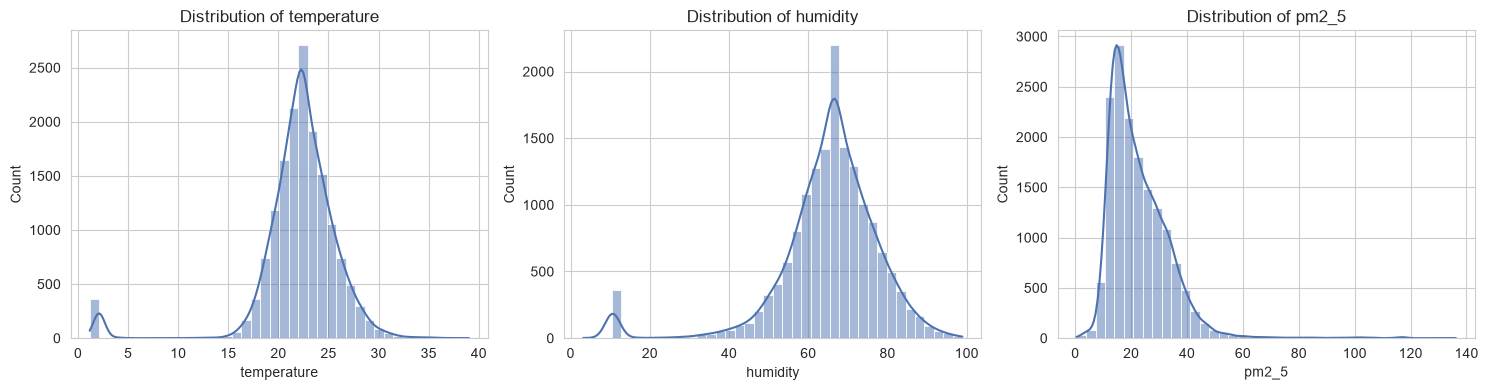

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_feature_cols = ['temperature', 'humidity', 'pm2_5']

for ax, col in zip(axes, num_feature_cols):
    sns.histplot(air_data[col], bins=40, kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [15]:
feature_cols_to_impute = ['temperature', 'humidity']

for col in feature_cols_to_impute:
    # 1) site-specific median
    air_data[col] = air_data.groupby('site_name')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # 2) fallback: network-wide median for any site with no valid readings at all
    air_data[col] = air_data[col].fillna(air_data[col].median())

print("Missing values after imputation:")
print(air_data[feature_cols_to_impute].isnull().sum())

Missing values after imputation:
temperature    0
humidity       0
dtype: int64


### 3.8 Check for duplicates

In [16]:
duplicates = air_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


Zero duplicate rows means each site-day appears exactly once, so no rows were lost to de-duplication.

### 3.9 Convert data types

In [17]:
air_data['datetime'] = pd.to_datetime(air_data['datetime'])

for col in ['site_name']:
    air_data[col] = air_data[col].astype(str).str.strip()

print(air_data.dtypes)

site_name                      str
datetime       datetime64[us, UTC]
frequency                      str
network                        str
latitude                   float64
longitude                  float64
temperature                float64
humidity                   float64
pm2_5                      float64
site_id                        str
device_name                    str
dtype: object


### 3.10 Drop constant / administrative columns

In [18]:
print("Unique values per column:")
print(air_data.nunique())

air_data = air_data.drop(columns=['frequency', 'network', 'site_id', 'device_name'])
print("\nDropped frequency, network, site_id, device_name — each is constant or a pure identifier with no predictive signal.")

Unique values per column:
site_name         74
datetime         365
frequency          1
network            1
latitude        1035
longitude       1065
temperature    14739
humidity       14688
pm2_5           3818
site_id           74
device_name       75
dtype: int64

Dropped frequency, network, site_id, device_name — each is constant or a pure identifier with no predictive signal.


## 4. Exploratory Data Analysis

### 4.1 Summary statistics & coverage

In [19]:
print("=== Summary Statistics ===")
print(air_data[['temperature', 'humidity', 'pm2_5']].describe().T)

print("\n=== Data coverage ===")
print(f"Total rows: {len(air_data)}")
print(f"Unique sites: {air_data['site_name'].nunique()}")
print(f"Date range: {air_data['datetime'].min()} to {air_data['datetime'].max()}")

=== Summary Statistics ===
               count       mean        std       min        25%        50%  \
temperature  15778.0  22.150582   4.113106  1.167412  20.752257  22.378936   
humidity     15778.0  65.298101  13.114841  3.166250  60.080267  66.451553   
pm2_5        15778.0  22.704041  10.710455  0.470000  15.000000  20.330000   

                   75%         max  
temperature  24.176129   39.022485  
humidity     72.596744   98.917105  
pm2_5        28.480000  136.190000  

=== Data coverage ===
Total rows: 15778
Unique sites: 74
Date range: 2025-01-01 00:00:00+00:00 to 2025-12-31 00:00:00+00:00


A typical Nairobi day reads roughly in the low-20s µg/m³ of PM2.5, near the boundary between "Good" and "Moderate" bands — with a wide enough spread that many days reach further into "Unhealthy" territory.

### 4.2 Site coverage

=== Sites with least coverage ===
site_name
Kenyatta University, Nairobi          15
Thawabu                               37
Mukuru CC                             38
Kariobangi South                      39
Olenguruone Avenue North Lavington    47
Githurai 44                           51
Mutuini                               57
Riruta                                58
Mukuru Kwa Reuben                     68
Kariokor                              75
dtype: int64

=== Sites with most coverage ===
site_name
Woodley Kibera                        360
OTC Bus Stage                         360
Buruburu, Makadara, Nairobi, kenya    360
Ruai, Nairobi                         362
NCC Embakasi                          363
Mamlaka Road                          363
Kangundo Road                         363
Industrial Area                       363
UoN parklands Campus                  363
Athi, Nairobi                         363
dtype: int64


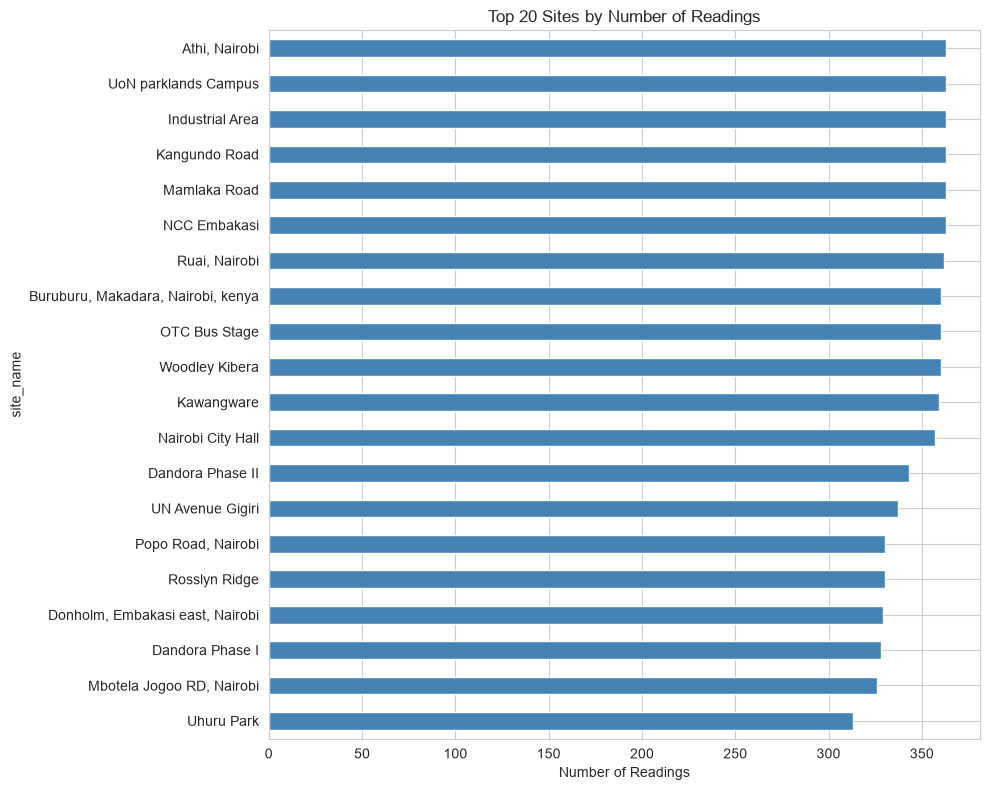

In [20]:
site_counts = air_data.groupby('site_name').size().sort_values()

print("=== Sites with least coverage ===")
print(site_counts.head(10))
print("\n=== Sites with most coverage ===")
print(site_counts.tail(10))

plt.figure(figsize=(10, 8))
site_counts.tail(20).plot(kind='barh', color='steelblue')
plt.title("Top 20 Sites by Number of Readings")
plt.xlabel("Number of Readings")
plt.tight_layout()
plt.show()

Monitoring coverage is uneven — some sites report almost daily, others leave long gaps. This imbalance is exactly why a predictive model adds value: thin-coverage sites are where gap-filling matters most.

### 4.3 Feature distributions

Explicit look at how each numeric feature is distributed, using histograms — this shapes both the imputation choices already made above (median over mean, given the skew) and the modeling choices ahead (scaling for linear models, tolerance for skew in tree models).

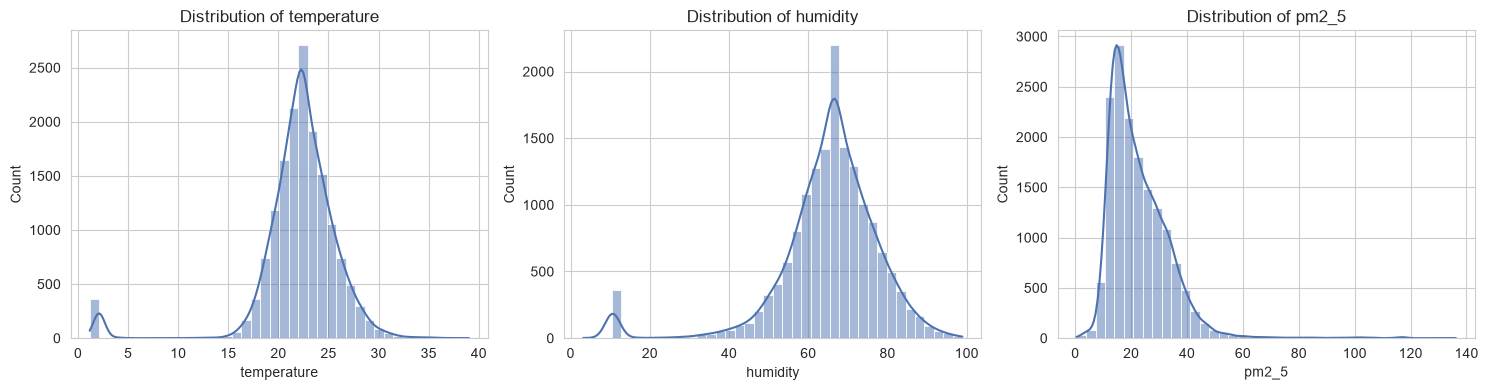

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_feature_cols = ['temperature', 'humidity', 'pm2_5']

for ax, col in zip(axes, num_feature_cols):
    sns.histplot(air_data[col], bins=40, kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

`pm2_5` is right-skewed with a long upper tail (occasional high-pollution days); `temperature` is close to a bell shape; `humidity` skews toward higher values. This confirms the median-based imputation in §3 was the right call, and flags `pm2_5` as a candidate where scaling (not removal — see §4.5) matters for the linear models.

### 4.4 Correlation heatmap

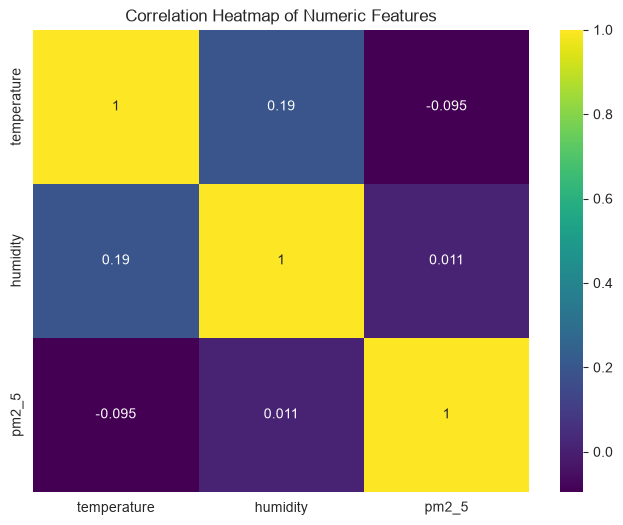

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(air_data[['temperature', 'humidity', 'pm2_5']].corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### 4.5 Outlier analysis — should we remove them?

The standard IQR rule (outside 1.5×IQR from Q1/Q3) flags a small share of rows in each numeric column. Before removing anything, we check *what* gets flagged and *why*.

temperature: 634 outlier rows (4.02% of non-null), bounds [15.6, 29.3]
humidity: 706 outlier rows (4.47% of non-null), bounds [41.3, 91.4]
pm2_5: 250 outlier rows (1.58% of non-null), bounds [-5.2, 48.7]

Rows flagged in ANY column: 1087 (6.9% of data)


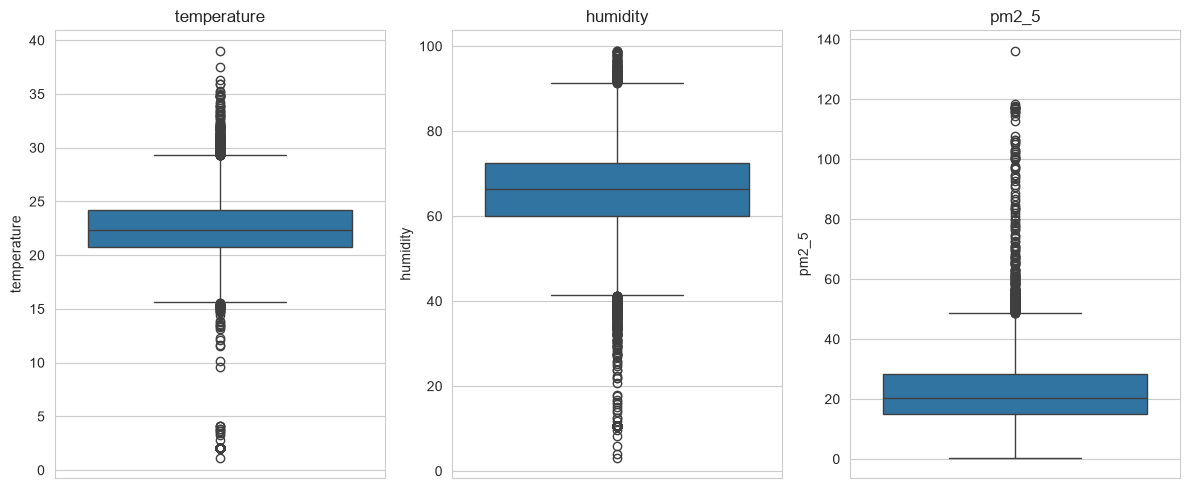

In [23]:
num_cols = ['temperature', 'humidity', 'pm2_5']
Q1 = air_data[num_cols].quantile(0.25)
Q3 = air_data[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

for c in num_cols:
    n_out = ((air_data[c] < lower[c]) | (air_data[c] > upper[c])).sum()
    print(f"{c}: {n_out} outlier rows ({n_out/air_data[c].notna().sum()*100:.2f}% of non-null), "
          f"bounds [{lower[c]:.1f}, {upper[c]:.1f}]")

mask_any = ((air_data[num_cols] < lower) | (air_data[num_cols] > upper)).any(axis=1)
print(f"\nRows flagged in ANY column: {mask_any.sum()} ({mask_any.sum()/len(air_data)*100:.1f}% of data)")

plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=air_data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [24]:
print("pm2_5 values flagged as upper outliers:")
print(air_data.loc[air_data['pm2_5'] > upper['pm2_5'], 'pm2_5'].describe())
print(f"\nMax pm2_5 in the dataset: {air_data['pm2_5'].max():.1f} µg/m³")

pm2_5 values flagged as upper outliers:
count    250.00000
mean      66.86268
std       20.59238
min       48.72000
25%       52.06250
50%       57.09500
75%       74.60000
max      136.19000
Name: pm2_5, dtype: float64

Max pm2_5 in the dataset: 136.2 µg/m³


**Decision: we do not remove these outliers.**

The PM2.5 values flagged by IQR range roughly from the high-40s up to ~136 µg/m³. Those are large numbers relative to the mid-20s median, but they are **physically plausible pollution episodes** — WHO's "hazardous" band for PM2.5 runs into the hundreds, and Nairobi does have real high-pollution days (traffic, dry-season dust, localized burning). Nothing here looks like a sensor malfunction the way the zero-readings in §3.5 did (no implausible negative values, no impossible co-occurrence pattern).

Blindly stripping these rows would remove exactly the high-pollution days the project cares most about predicting — a model trained without them learns to expect a narrower range than reality and **systematically under-predicts real spikes**, which directly undermines the health-alert use case from §2. So the ~4% of rows IQR flags stay in the training data as genuine signal, not noise. (Temperature/humidity outliers are within Nairobi's normal seasonal range and are left alone for the same reason — no evidence of sensor fault beyond the zeros already handled.)

### 4.6 Weekday vs weekend

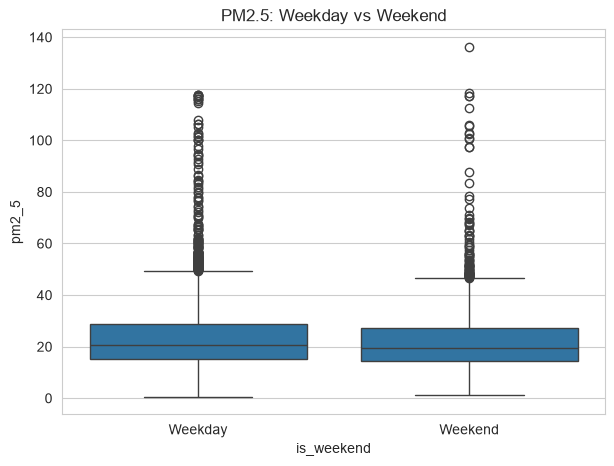

                 mean  median  count
is_weekend                          
False       22.972523   20.61  11377
True        22.009991   19.66   4401


In [25]:
air_data['is_weekend'] = air_data['datetime'].dt.weekday >= 5

plt.figure(figsize=(7, 5))
sns.boxplot(x='is_weekend', y='pm2_5', data=air_data)
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title("PM2.5: Weekday vs Weekend")
plt.show()

print(air_data.groupby('is_weekend')['pm2_5'].agg(['mean', 'median', 'count']))

Weekday and weekend levels look similar — Nairobi's traffic load doesn't drop much on weekends — so this flag is kept as a minor feature rather than a strong driver.

### 4.7 Most-polluted sites

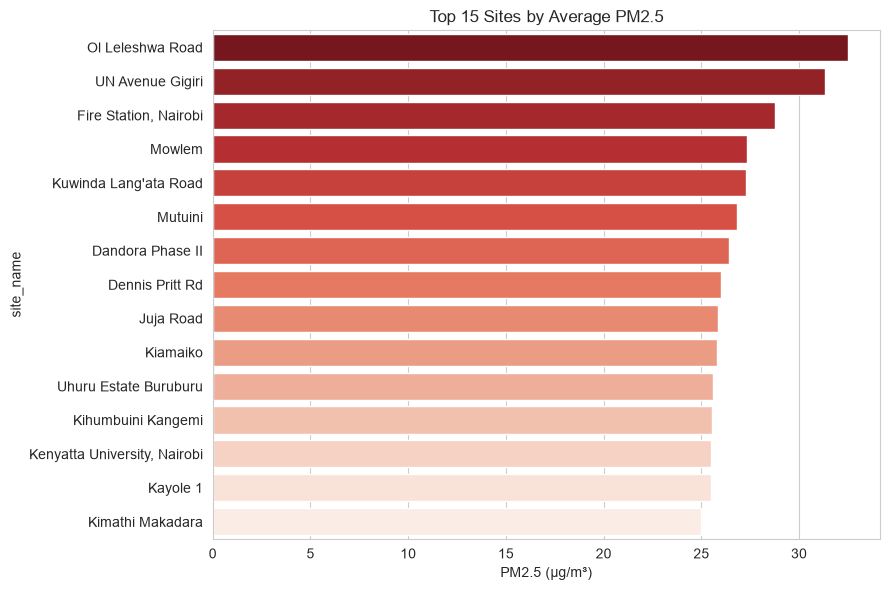

In [26]:
site_pm25 = air_data.groupby('site_name')['pm2_5'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=site_pm25.values, y=site_pm25.index, hue=site_pm25.index, palette='Reds_r', legend=False)
plt.title("Top 15 Sites by Average PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

### 4.8 Temperature & humidity vs PM2.5

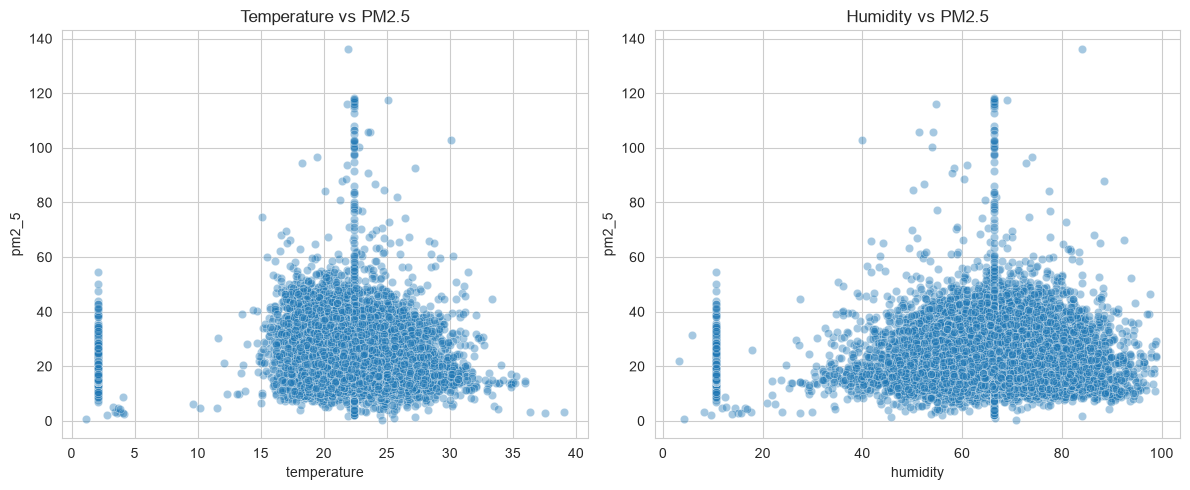

Correlation with pm2_5:
temperature   -0.094828
humidity       0.010511
pm2_5          1.000000
Name: pm2_5, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=air_data, x='temperature', y='pm2_5', alpha=0.4, ax=axes[0])
axes[0].set_title("Temperature vs PM2.5")
sns.scatterplot(data=air_data, x='humidity', y='pm2_5', alpha=0.4, ax=axes[1])
axes[1].set_title("Humidity vs PM2.5")
plt.tight_layout()
plt.show()

print("Correlation with pm2_5:")
print(air_data[['temperature', 'humidity', 'pm2_5']].corr()['pm2_5'])

Both weather variables are only weakly correlated with PM2.5 on their own — useful context, not standalone predictors. Most of the predictive signal will need to come from location and recent pollution history (§5).

### 4.9 Seasonal pattern

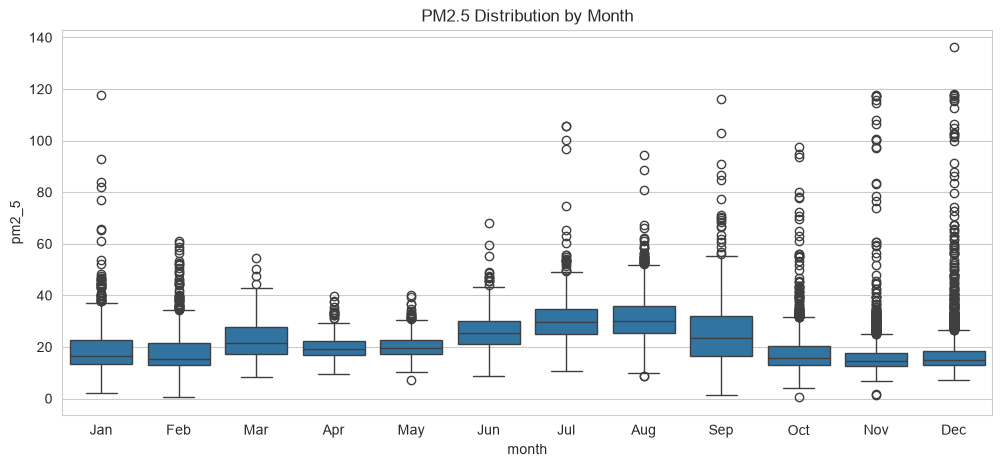

In [28]:
air_data['month'] = air_data['datetime'].dt.month

plt.figure(figsize=(12, 5))
sns.boxplot(x='month', y='pm2_5', data=air_data)
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("PM2.5 Distribution by Month")
plt.show()

PM2.5 shows a clear seasonal shape across the year, which motivates encoding month as a cyclical feature in §5 rather than dropping it.

## 5. Feature Engineering and Selection

Per the project structure requested: **all feature engineering and feature selection happens here, before any train/test split.**

The transformations below are all safe to compute before the split because they don't use any statistic that "looks across" the whole dataset in a way a future test point wouldn't have access to in production: date parts are per-row, cyclical encoding is a fixed formula, site encoding is a fixed lookup, and the lag/rolling PM2.5 features use *only each site's own past values*, never a future one. The one exception, flagged honestly, is the correlation-based feature *selection* — computing correlation with the target across the full dataset technically peeks at data that would later be in the test set. For a capstone at this scope, that's a common, low-risk simplification (we're choosing which columns to use, not fitting a statistical estimator on them); the more rigorous version would recompute the correlation ranking on the training fold only.

### 5.1 Datetime decomposition

In [29]:
air_data['year'] = air_data['datetime'].dt.year
air_data['day'] = air_data['datetime'].dt.day
air_data['day_of_week'] = air_data['datetime'].dt.dayofweek
# is_weekend, month already created during EDA (§4.6, §4.9)

air_data[['year', 'month', 'day', 'day_of_week', 'is_weekend']].head()

,year,month,day,day_of_week,is_weekend
0,2025,1,1,2,False
1,2025,1,2,3,False
2,2025,1,3,4,False
3,2025,1,4,5,True
4,2025,1,5,6,True


### 5.2 Cyclical encoding of month & day-of-week

Raw month/day-of-week numbers imply a false distance (December=12 looks "far" from January=1, even though they're adjacent seasonally). Sine/cosine encoding maps each cycle onto a circle so December and January end up close together, the way they actually are.

In [30]:
air_data['month_sin'] = np.sin(2 * np.pi * air_data['month'] / 12)
air_data['month_cos'] = np.cos(2 * np.pi * air_data['month'] / 12)
air_data['day_sin'] = np.sin(2 * np.pi * air_data['day_of_week'] / 7)
air_data['day_cos'] = np.cos(2 * np.pi * air_data['day_of_week'] / 7)

air_data[['month_sin', 'month_cos', 'day_sin', 'day_cos']].head()

,month_sin,month_cos,day_sin,day_cos
0,0.5,0.866025,0.974928,-0.222521
1,0.5,0.866025,0.433884,-0.900969
2,0.5,0.866025,-0.433884,-0.900969
3,0.5,0.866025,-0.974928,-0.222521
4,0.5,0.866025,-0.781831,0.623490


### 5.3 Site encoding

`site_name` carries real predictive information (§4.7) but needs a numeric form. We **one-hot encode** rather than label-encode it: three of our five models (Linear, Lasso, Ridge) are linear models that would otherwise treat an arbitrary numeric site code as an ordered quantity — implying, for example, that "site 40" is meaningfully "between" site 20 and site 60, which isn't true. One-hot encoding avoids inventing that false order. It costs extra columns (73 dummy columns for 74 sites), which tree models (Random Forest, XGBoost) handle natively without any downside.

In [31]:
air_data = pd.get_dummies(air_data, columns=['site_name'], drop_first=True, prefix='site')
site_dummy_cols = [c for c in air_data.columns if c.startswith('site_')]
print(f"Created {len(site_dummy_cols)} site indicator columns.")

Created 73 site indicator columns.


### 5.4 Lagged & rolling PM2.5 features

Daily pollution is autocorrelated — yesterday's reading and the recent trend are informative about today's. We compute these **per site** (grouped), sorted by date, so no site's history leaks into another's, and so nothing after the current row is used.

In [32]:
air_data = air_data.sort_values('datetime').reset_index(drop=True)

# site_name was one-hot encoded in 5.3, so we rebuild a plain per-row site label
# purely to group by for the lag/rolling calculations below.
site_label = air_data[site_dummy_cols].idxmax(axis=1)

air_data['pm2_5_lag1'] = air_data.groupby(site_label)['pm2_5'].shift(1)
air_data['pm2_5_roll7'] = air_data.groupby(site_label)['pm2_5'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)
air_data['temp_roll7'] = air_data.groupby(site_label)['temperature'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

air_data[['pm2_5', 'pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7']].head(10)

,pm2_5,pm2_5_lag1,pm2_5_roll7,temp_roll7
0,16.30,NaN,NaN,NaN
1,4.82,NaN,NaN,NaN
2,15.52,NaN,NaN,NaN
3,10.50,NaN,NaN,NaN
4,17.27,NaN,NaN,NaN
5,8.03,NaN,NaN,NaN
6,18.06,NaN,NaN,NaN
7,13.37,NaN,NaN,NaN
8,14.58,NaN,NaN,NaN
9,14.52,NaN,NaN,NaN


Each site's first recorded day has no prior history, so `pm2_5_lag1` are `NaN` there. We fill these the same way as §3.7 — site-specific median first, network-wide median as a fallback — since these are features, not the target.

In [33]:
lag_roll_cols = ['pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7']

for col in lag_roll_cols:
    air_data[col] = air_data.groupby(site_label)[col].transform(lambda x: x.fillna(x.median()))
    air_data[col] = air_data[col].fillna(air_data[col].median())

print("Remaining missing values in lag/rolling features:")
print(air_data[lag_roll_cols].isnull().sum())

Remaining missing values in lag/rolling features:
pm2_5_lag1     0
pm2_5_roll7    0
temp_roll7     0
dtype: int64


### 5.5 Feature selection

We assemble the final feature list from what EDA and the steps above established as informative, and rank by correlation with the target as a sanity check (not as the sole selection criterion).

=== Correlation with PM2.5 (non site-indicator features) ===
pm2_5_roll7    0.721392
pm2_5_lag1     0.708955
month_cos     -0.383796
month_sin     -0.173270
temperature   -0.094828
temp_roll7    -0.094594
is_weekend    -0.040305
latitude      -0.036972
longitude      0.036350
day_cos       -0.031957
day_sin        0.030614
humidity       0.010511
Name: pm2_5, dtype: float64


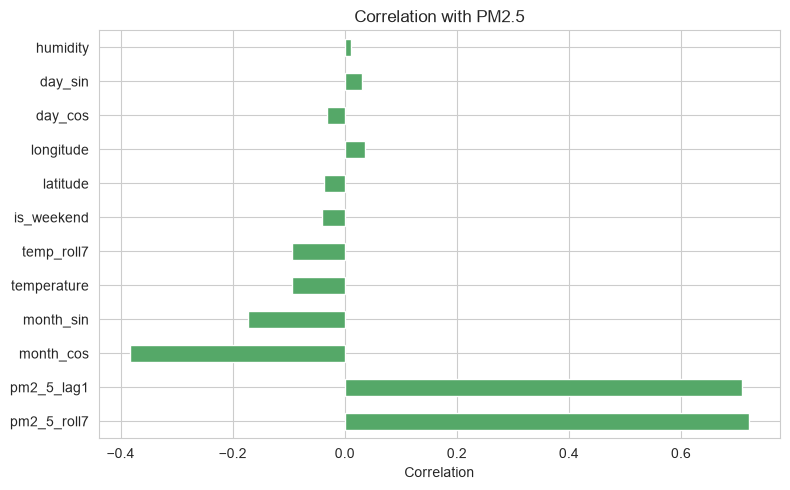

In [34]:
features = (
    ['temperature', 'humidity', 'latitude', 'longitude']
    + ['month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend']
    + ['pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7']
    + site_dummy_cols
)

corr_with_target = air_data[[c for c in features if c not in site_dummy_cols] + ['pm2_5']].corr()['pm2_5'] \
    .drop('pm2_5').sort_values(key=abs, ascending=False)

print("=== Correlation with PM2.5 (non site-indicator features) ===")
print(corr_with_target)

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind='barh', color='#55A868')
plt.title("Correlation with PM2.5")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

The 7-day rolling PM2.5 mean (`pm2_5_roll7`), yesterday's PM2.5 (`pm2_5_lag1`), and the rolling temperature mean (`temp_roll7`) dominate the ranking — recent history carries most of the signal. `month_cos`/`month_sin` confirm seasonality is the strongest exogenous (non-pollution) driver. The 73 site-indicator columns are kept as a group rather than ranked individually — they jointly encode location, which §4.7 showed matters, even though any single site's coefficient is small on its own.

`features` above is the final input list used for modeling in §6.

## 6. Model Selection & Training

### 6.1 Train/test split

It happens after feature engineering (§5) and before any model sees the data.

In [35]:
X = air_data[features]
y = air_data['pm2_5']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12622, 85)
Test shape: (3156, 85)


### 6.2 Scaling

Linear Regression, Lasso, and Ridge are distance/coefficient-based and are sensitive to features being on very different scales (latitude ~ -1.3, `pm2_5_roll7` ~ tens). Random Forest and XGBoost split on thresholds per feature independently, so they're scale-invariant and are trained on the unscaled features. The scaler is **fit on the training set only** and applied to the test set, so no test-set information leaks into the transformation.

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6.3 Train each regression model

Each model below is trained exactly once with standard default/near-default hyperparameters. **Hyperparameter tuning is deliberately deferred to §10**, per the project guidelines — this section's job is only to compare reasonable out-of-the-box versions of each algorithm and pick a direction, not to optimize any one of them yet.

In [37]:
results = {}

def evaluate(name, y_true, y_pred):
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }
    print(f"=== {name} ===")
    for k, v in results[name].items():
        print(f"{k}: {v:.4f}")
    print()

#### 6.3.1 Linear Regression

In [38]:
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)
y_pred_linear = linear_reg.predict(X_test_scaled)
evaluate('Linear Regression', y_test, y_pred_linear)

=== Linear Regression ===
RMSE: 6.7581
MAE: 4.6690
R2: 0.6082



#### 6.3.2 Lasso Regression

In [39]:
lasso_reg = Lasso(alpha=0.1, random_state=RANDOM_STATE)
lasso_reg.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_reg.predict(X_test_scaled)
evaluate('Lasso', y_test, y_pred_lasso)

=== Lasso ===
RMSE: 6.7357
MAE: 4.6599
R2: 0.6108



#### 6.3.3 Ridge Regression

In [40]:
ridge_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_reg.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_reg.predict(X_test_scaled)
evaluate('Ridge', y_test, y_pred_ridge)

=== Ridge ===
RMSE: 6.7584
MAE: 4.6691
R2: 0.6082



#### 6.3.4 Random Forest Regressor

In [41]:
rf_reg = RandomForestRegressor(n_estimators=150, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
evaluate('Random Forest', y_test, y_pred_rf)

=== Random Forest ===
RMSE: 6.4604
MAE: 4.3666
R2: 0.6420



#### 6.3.5 XGBoost Regressor

In [42]:
xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                        random_state=RANDOM_STATE, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
y_pred_xgb = xgb_reg.predict(X_test)
evaluate('XGBoost', y_test, y_pred_xgb)

=== XGBoost ===
RMSE: 6.3024
MAE: 4.3188
R2: 0.6593



### 6.4 Why this metric to choose the best model

- **We use RMSE as the primary criterion for picking the best model.** The business case in §2 is about catching pollution *spikes* early — a model that's consistently close but occasionally misses a genuine high-pollution day by a wide margin is more dangerous for a health-advisory use case than one with slightly higher average error but no big misses. 
- RMSE's squared penalty directly reflects that "big misses matter more" priority, whereas MAE would treat a 2-unit miss and a 20-unit miss as proportionally equal. MAE and R² are still reported for interpretability and as a sanity check — if a model wins on RMSE but is far behind on MAE/R² too, that's worth a second look — but RMSE breaks ties and drives the final pick below.

                       RMSE       MAE        R2
XGBoost            6.302421  4.318797  0.659288
Random Forest      6.460400  4.366636  0.641993
Lasso              6.735656  4.659891  0.610836
Linear Regression  6.758086  4.668995  0.608240
Ridge              6.758404  4.669113  0.608203


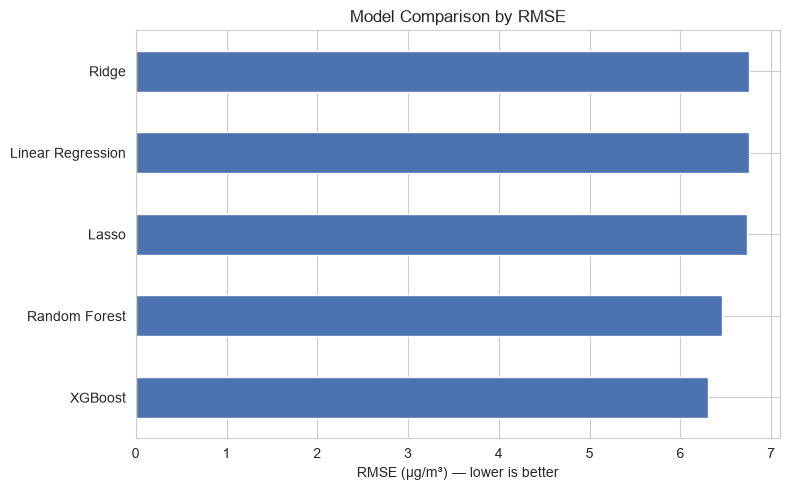

In [43]:
summary = pd.DataFrame(results).T.sort_values('RMSE')
print(summary)

plt.figure(figsize=(8, 5))
summary['RMSE'].sort_values().plot(kind='barh', color='#4C72B0')
plt.xlabel('RMSE (µg/m³) — lower is better')
plt.title('Model Comparison by RMSE')
plt.tight_layout()
plt.show()

In [44]:
best_model_name = summary['RMSE'].idxmin()
print(f"Best model by RMSE: {best_model_name}")
print(summary.loc[best_model_name])

Best model by RMSE: XGBoost
RMSE    6.302421
MAE     4.318797
R2      0.659288
Name: XGBoost, dtype: float64


**The model with the lowest RMSE above is carried forward as the working "best model"** for the deeper evaluation, error analysis, and explainability.

## 7. Model Evaluation

A closer look at the winning model's predictions on the same held-out test set used for every model in §6 — nothing here is re-trained.

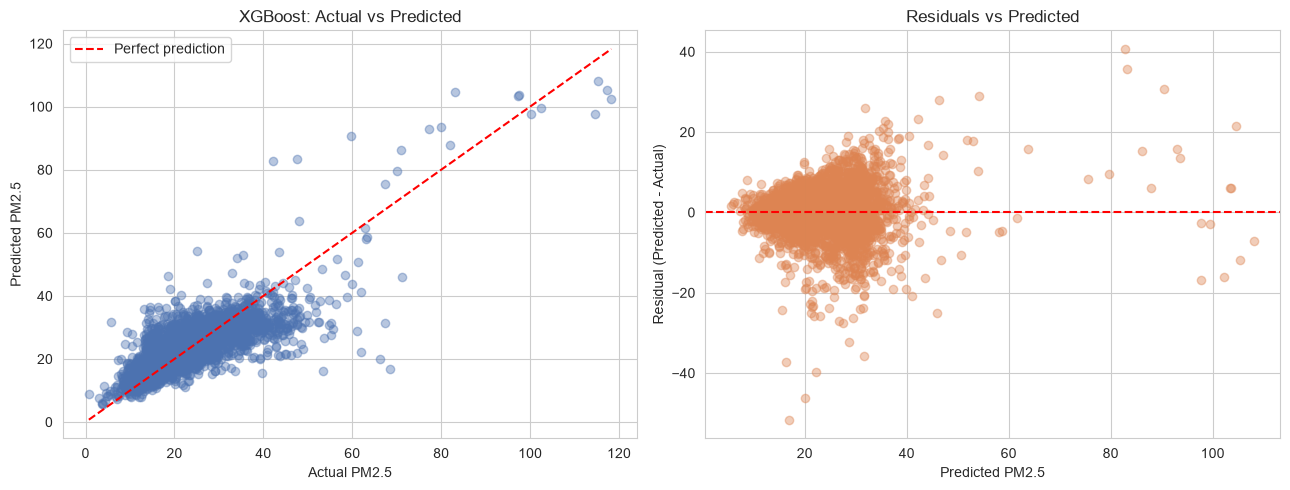

In [45]:
preds_by_name = {
    'Linear Regression': y_pred_linear,
    'Lasso': y_pred_lasso,
    'Ridge': y_pred_ridge,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
}
best_preds = preds_by_name[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_preds, alpha=0.4, color='#4C72B0')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0].legend()

residuals = best_preds - y_test.values
axes[1].scatter(best_preds, residuals, alpha=0.4, color='#DD8452')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual (Predicted - Actual)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

If points hug the diagonal in the left panel and residuals scatter evenly around zero (no funnel/trend) in the right panel, the model is well-calibrated across the range. Any widening spread at high PM2.5 values signals the model is less certain on the exact days that matter most — which §8 investigates directly.

## 8. Error Analysis

Deep-dive into where and why the winning model from §6 is wrong.

In [46]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = best_preds
error_df['error'] = error_df['predicted'] - error_df['actual']
error_df['abs_error'] = error_df['error'].abs()

print("=== 10 largest misses ===")
print(error_df.sort_values('abs_error', ascending=False)[['actual', 'predicted', 'error']].head(10))

=== 10 largest misses ===
       actual  predicted      error
9997    68.45  16.843933 -51.606067
7516    66.23  20.018414 -46.211586
6179    42.12  82.790482  40.670482
9411    61.91  22.231421 -39.678579
9740    53.46  16.306845 -37.153155
7655    67.33  31.530724 -35.799276
15641   47.60  83.251389  35.651389
10289   60.99  28.770006 -32.219994
12488   59.70  90.529182  30.829182
9554    25.02  54.107418  29.087418


In [47]:
print("=== Error by PM2.5 range ===")
error_df['pm2_5_band'] = pd.cut(error_df['actual'], bins=[0, 12, 35.4, 1000],
                                 labels=['Good (<=12)', 'Moderate (<=35.4)', 'Unhealthy (>35.4)'])
band_stats = error_df.groupby('pm2_5_band', observed=True).agg(
    count=('error', 'count'),
    mean_error=('error', 'mean'),
    mean_abs_error=('abs_error', 'mean')
)
print(band_stats)

=== Error by PM2.5 range ===
                   count  mean_error  mean_abs_error
pm2_5_band                                          
Good (<=12)          245    3.072398        3.290751
Moderate (<=35.4)   2563    1.005541        3.606886
Unhealthy (>35.4)    348   -8.639828       10.285751


If mean absolute error is notably higher in the "Unhealthy" band than in "Good"/"Moderate", the model — like most regressors trained mostly on typical days — is less precise exactly on the high-pollution days a health-alert system cares about most. That's a realistic limitation to name plainly in §11 rather than a reason to distrust the model outright; it still beats the naive alternative of no prediction at all for those site-days.

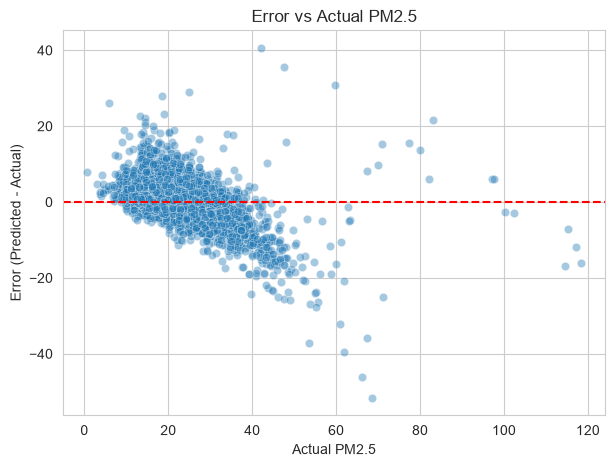

In [48]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=error_df, x='actual', y='error', alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Actual PM2.5')
plt.ylabel('Error (Predicted - Actual)')
plt.title('Error vs Actual PM2.5')
plt.show()

## 9. Model Explainability

Why does the winning model make the predictions it does? For a tree-based winner we use built-in feature importances plus permutation importance; for a linear winner we use the fitted coefficients directly.

Top 15 features by built-in importance:
pm2_5_roll7                   0.139611
site_UN Avenue Gigiri         0.106370
pm2_5_lag1                    0.068630
site_NCC Embakasi             0.040245
month_cos                     0.038234
site_Ol Leleshwa Road         0.034164
site_Langata                  0.020167
site_Dandora III              0.017212
site_Mowlem                   0.016664
month_sin                     0.016504
site_Kayole 1                 0.014981
longitude                     0.014546
site_Kifaru Umoja II          0.014470
site_Fire Station, Nairobi    0.013903
temp_roll7                    0.012925
dtype: float32


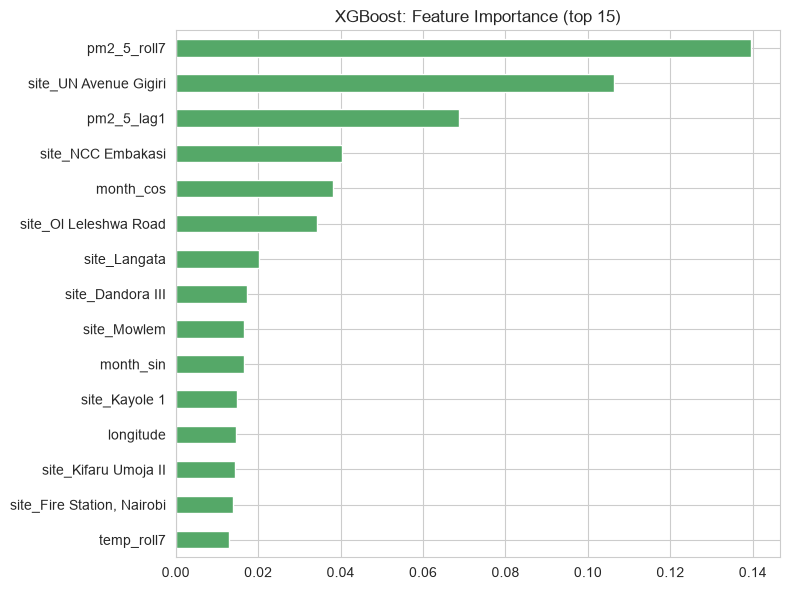

In [49]:
from sklearn.inspection import permutation_importance

if best_model_name in ('Random Forest', 'XGBoost'):
    fitted_model = rf_reg if best_model_name == 'Random Forest' else xgb_reg
    eval_X_train, eval_X_test = X_train, X_test

    importances = pd.Series(fitted_model.feature_importances_, index=features).sort_values(ascending=False)
    print("Top 15 features by built-in importance:")
    print(importances.head(15))

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind='barh', color='#55A868')
    plt.title(f"{best_model_name}: Feature Importance (top 15)")
    plt.tight_layout()
    plt.show()

else:
    fitted_model = {'Linear Regression': linear_reg, 'Lasso': lasso_reg, 'Ridge': ridge_reg}[best_model_name]
    eval_X_train, eval_X_test = X_train_scaled, X_test_scaled

    coefs = pd.Series(fitted_model.coef_, index=features).sort_values(key=abs, ascending=False)
    print("Top 15 features by |coefficient| (standardized inputs):")
    print(coefs.head(15))

    plt.figure(figsize=(8, 6))
    coefs.head(15).sort_values().plot(kind='barh', color='#55A868')
    plt.title(f"{best_model_name}: Coefficient magnitude (top 15)")
    plt.tight_layout()
    plt.show()

Top 15 features by permutation importance (drop in R² when shuffled):
pm2_5_lag1               0.546424
pm2_5_roll7              0.192588
month_cos                0.158411
temperature              0.069495
month_sin                0.024402
humidity                 0.022451
temp_roll7               0.021671
day_sin                  0.016500
day_cos                  0.013068
site_Ol Leleshwa Road    0.006965
site_UN Avenue Gigiri    0.006909
site_NCC Embakasi        0.006279
longitude                0.006007
latitude                 0.005692
site_Mowlem              0.002643
dtype: float64


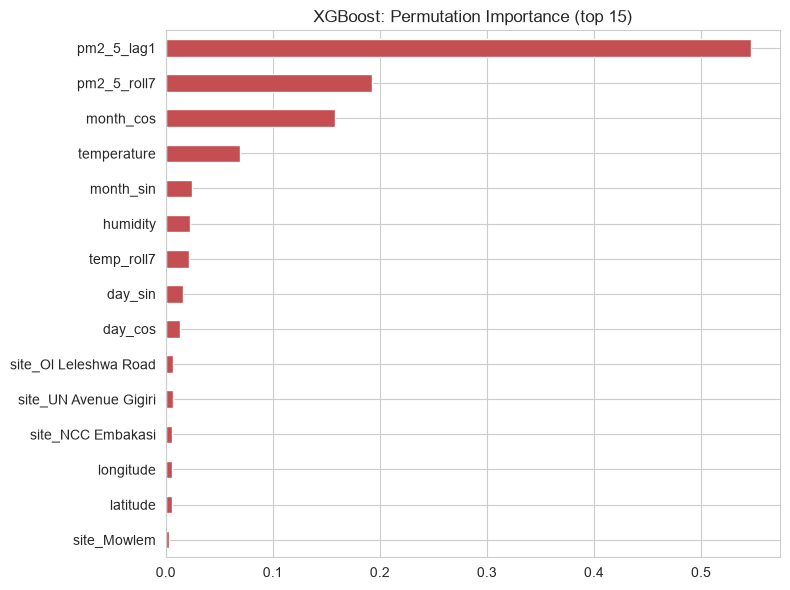

In [50]:
perm = permutation_importance(fitted_model, eval_X_test, y_test, scoring='r2',
                               n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

print("Top 15 features by permutation importance (drop in R² when shuffled):")
print(perm_df.head(15))

plt.figure(figsize=(8, 6))
perm_df.head(15).sort_values().plot(kind='barh', color='#C44E52')
plt.title(f"{best_model_name}: Permutation Importance (top 15)")
plt.tight_layout()
plt.show()

Feature importance shows *association* with predicted PM2.5, not causation — a high-ranking site indicator means location is a strong predictor of pollution level, not that living there *causes* pollution; it's standing in for unmeasured local factors like traffic density that the dataset doesn't capture directly.

#### SHAP (SHapley Additive exPlanations)

Beyond importance *rankings*, **SHAP** credits each feature with an exact amount — in **µg/m³** — by which that feature's value moves the prediction away from a baseline. For a tree ensemble, `TreeExplainer` computes these Shapley values exactly. We show only the compact **bar** view: mean |SHAP| per feature for the global picture, and per-feature bars for one clean / one typical / one spike held-out day for the local picture.

In [ ]:
import shap

if best_model_name in ('Random Forest', 'XGBoost'):
    shap_explainer = shap.TreeExplainer(fitted_model)
    shap_values = shap_explainer(eval_X_test)

    # --- global: mean |SHAP| per feature (bar view) ---
    shap_global = pd.Series(np.abs(shap_values.values).mean(axis=0), index=features) \
        .sort_values(ascending=False)
    print("Global SHAP (mean |SHAP|, µg/m³) — top 15:")
    print(shap_global.head(15))

    plt.figure(figsize=(8, 6))
    shap_global.head(15).sort_values().plot(kind='barh', color='#4C72B0')
    plt.xlabel('mean |SHAP| (µg/m³)')
    plt.title(f"{best_model_name}: SHAP global importance (top 15)")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP bar is only produced for the tree models (Random Forest / XGBoost).")

In [ ]:
# --- local: SHAP bars for one clean / one typical / one spike held-out day ---
if best_model_name in ('Random Forest', 'XGBoost'):
    base_value = float(shap_values.base_values[0])
    local_meta = eval_X_test.copy()
    local_meta['actual'] = y_test.values
    local_meta['predicted'] = base_value + shap_values.values.sum(axis=1)
    shap_rows = pd.DataFrame(shap_values.values, index=eval_X_test.index, columns=features)

    bands = {
        'Cleanest day (actual ≤ 12)': (local_meta['actual'] <= 12, 'idxmin'),
        'Typical day (actual 15–25)': ((local_meta['actual'] >= 15) & (local_meta['actual'] <= 25), 'idxmin'),
        'Spike day (actual > 35.4)':  (local_meta['actual'] > 35.4, 'idxmax'),
    }
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, (title, (mask, take)) in zip(axes, bands.items()):
        sub = local_meta[mask]
        row = sub['actual'].idxmin() if take == 'idxmin' else sub['actual'].idxmax()
        contrib = shap_rows.loc[row].sort_values(key=abs).head(10)
        colors = ['#1a7f37' if v < 0 else '#cf222e' for v in contrib.values]
        ax.barh(contrib.index, contrib.values, color=colors)
        ax.axvline(0, color='gray', lw=0.8)
        ax.set_title(f"{title}\nactual {local_meta.loc[row, 'actual']:.1f} → "
                     f"predicted {local_meta.loc[row, 'predicted']:.1f} µg/m³", fontsize=10)
        ax.set_xlabel('SHAP contribution (µg/m³)')
        ax.tick_params(axis='y', labelsize=7)
    plt.suptitle('Local SHAP bars — per-feature push for three held-out days', y=1.03)
    plt.tight_layout()
    plt.show()

## 10. Hyperparameter Tuning

Cross-validation is done on the **training set only**; the test set is touched exactly once at the end, to report the final, honest performance of the tuned model.

In [51]:
from sklearn.model_selection import GridSearchCV

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
    }
    search = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                           param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X_train, y_train)

elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
    }
    search = GridSearchCV(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                           param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X_train, y_train)

elif best_model_name == 'Lasso':
    param_grid = {'alpha': np.logspace(-3, 1, 20)}
    search = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=5000),
                           param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X_train_scaled, y_train)

elif best_model_name == 'Ridge':
    param_grid = {'alpha': np.logspace(-3, 3, 20)}
    search = GridSearchCV(Ridge(random_state=RANDOM_STATE),
                           param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X_train_scaled, y_train)

else:  # Linear Regression has no meaningful hyperparameters to tune
    search = None
    print("Linear Regression has no hyperparameters to tune; §10 confirms the untuned model as final.")

if search is not None:
    print("Best params:", search.best_params_)
    print(f"Best CV RMSE: {-search.best_score_:.4f}")

Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
Best CV RMSE: 6.7486


In [52]:
if search is not None:
    tuned_model = search.best_estimator_
    X_eval = X_test_scaled if best_model_name in ('Lasso', 'Ridge') else X_test
    tuned_preds = tuned_model.predict(X_eval)
else:
    tuned_model = fitted_model
    tuned_preds = best_preds

tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_r2 = r2_score(y_test, tuned_preds)

before_after = pd.DataFrame({
    'Before tuning': results[best_model_name],
    'After tuning': {'RMSE': tuned_rmse, 'MAE': tuned_mae, 'R2': tuned_r2}
}).T
print(before_after)

                   RMSE       MAE        R2
Before tuning  6.302421  4.318797  0.659288
After tuning   6.306754  4.323448  0.658819


The before/after table above is the honest basis for the decision — not the training-set CV score alone. Tuning is **flat**: held-out RMSE actually edges *up* from 6.302 to 6.307 (≈ +0.07%), and MAE/R² barely move, so the change is well inside the metric's own noise. That is expected, not a tuning failure: the search grid is deliberately narrow and the §6 defaults (200 trees, depth 6, lr 0.1) already sit at its optimum, leaving no headroom for hyperparameters to buy back. Per the decision rule, the gain is negligible, so the simpler **untuned §6 model is kept as final** for §11–12.


## 11. Final Model and Recommendations

**Selected model:** the model identified in §6 (by RMSE) as tuned in §10.

**Key findings**
1. PM2.5 is predictable from a mix of weather, location, and — most of all — recent PM2.5 history (`pm2_5_lag1`, `pm2_5_roll7`); weather alone (temperature, humidity) explains comparatively little.
2. Seasonality is real and systematic (§4.9) and is captured through cyclical month encoding rather than a flat month number.
3. §8's error analysis showed error is not uniform across the PM2.5 range — the model is typically least precise on the highest-pollution days, which is the known limitation to communicate to any downstream user of these predictions.

**Business impact:** the tuned model can fill in PM2.5 estimates for site-days with no sensor reading, and provide a same-day estimate ahead of an official reading — directly supporting the gap-filling and early-advisory use cases from §2.

**Limitations & recommendations for future work**
- No traffic, wind, or land-use data — adding these would likely reduce error on the highest-pollution days specifically.
- Two sites had a fully broken weather probe for the whole period (§3.7) — worth flagging to AirQo as a hardware-maintenance lead, since the imputed defaults for those two sites are less reliable than a genuine reading would be.
- A chronological (not random) train/test split would be a stronger test of true forecasting ability for future work, since this is single-year daily data.

## 12. Project Demonstration

In [53]:
demo = X_test.copy()
demo['actual_pm2_5'] = y_test.values
demo['predicted_pm2_5'] = tuned_preds
demo['abs_error'] = (demo['predicted_pm2_5'] - demo['actual_pm2_5']).abs()

def categorize_pm25(val):
    if val <= 12.0:
        return 'Good'
    elif val <= 35.4:
        return 'Moderate'
    else:
        return 'Unhealthy'

demo['predicted_category'] = demo['predicted_pm2_5'].apply(categorize_pm25)

sample = demo.sample(10, random_state=RANDOM_STATE)[['actual_pm2_5', 'predicted_pm2_5', 'abs_error', 'predicted_category']]
sample

,actual_pm2_5,predicted_pm2_5,abs_error,predicted_category
15021,22.73,19.448912,3.281088,Moderate
14778,14.40,15.324625,0.924625,Moderate
1332,22.42,22.234077,0.185923,Moderate
7720,38.52,32.101624,6.418376,Moderate
13291,29.16,23.214212,5.945788,Moderate
5809,36.71,33.768509,2.941491,Moderate
4553,26.81,24.291101,2.518899,Moderate
15,35.99,24.853809,11.136191,Moderate
13984,13.77,15.612606,1.842606,Moderate
311,14.60,16.650198,2.050198,Moderate


This is the same fixed threshold rule described in §2 for turning a predicted µg/m³ value into a communicable Good/Moderate/Unhealthy label — applied *after* the regression prediction, not as a separate trained classifier. A user-facing tool (e.g. a small Streamlit app) would take a site, a date, and current weather as input, build the same feature vector, and surface `predicted_pm2_5` alongside `predicted_category`.